In [1]:
!pip install focal-loss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2025-12-22 04:40:04.326077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766378404.488101      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766378404.537054      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
model_name = 'VGG19'
model_name

'VGG19'

In [9]:
preprocess_fn = applications.vgg19.preprocess_input

In [10]:
def build_data_augmentation(SEED=24520152):
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name='data_augmentation')

In [11]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [12]:
def build_vgg19(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a VGG19 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name="input_layer")

    backbone = applications.VGG19(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [13]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_vgg19()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [14]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_classifier(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_6_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('vgg19')
    backbone.trainable = True
    
    set_trainable = False
    for layer in backbone.layers:
        if layer.name == f'block{block}_conv1':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [16]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_block(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
        block=block,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [17]:
acc_b6 = []
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 6
Found 542 files belonging to 3 classes.


I0000 00:00:1766378419.498920      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

None
Epoch 1/50


I0000 00:00:1766378436.471164     118 service.cc:148] XLA service 0x7c939400d800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766378436.471785     118 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766378436.932886     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.5078 - loss: 2.1548  

I0000 00:00:1766378445.440371     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4847 - loss: 1.7305
Epoch 1: val_accuracy improved from -inf to 0.78782, saving model to /kaggle/working/VGG19_block_6_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 59s 492ms/step - accuracy: 0.4852 - loss: 1.7275 - val_accuracy: 0.7878 - val_loss: 0.4510 - learning_rate: 0.0010
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6635 - loss: 0.8401
Epoch 2: val_accuracy improved from 0.78782 to 0.80627, saving model to /kaggle/working/VGG19_block_6_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.6635 - loss: 0.8396 - val_accuracy: 0.8063 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7053 - loss: 0.6051
Epoch 3: val_accuracy did not improve from 0.80627
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.7053 - loss: 0.6047 - val_accuracy: 0.7731 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/st

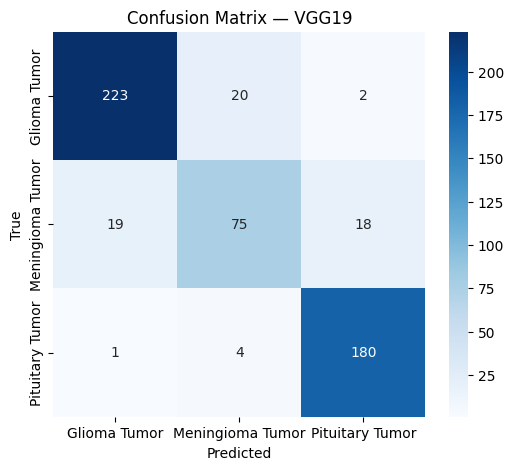

Fold: 1 block 5


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,029,003 (76.40 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7940 - loss: 0.2119
Epoch 1: val_accuracy improved from -inf to 0.88376, saving model to /kaggle/working/VGG19_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 288ms/step - accuracy: 0.7942 - loss: 0.2116 - val_accuracy: 0.8838 - val_loss: 0.0848 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8529 - loss: 0.1250
Epoch 2: val_accuracy improved from 0.88376 to 0.89299, saving model to /kaggle/working/VGG19_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.8530 - loss: 0.1250 - val_accuracy: 0.8930 - val_loss: 0.0781 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8700 - loss: 0.1096
Epoch 3: val_accuracy improved from 0.89299 to 0.90590, saving model to /kaggle/working/VGG19_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.8700 - loss: 0.1096 - val_accuracy: 0.9059 - va

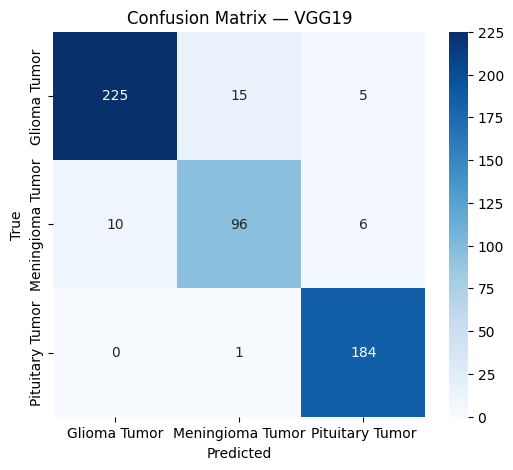

Fold: 1 block 4


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,907,467 (148.42 MB)

 Trainable params: 9,440,771 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 18,881,544 (72.03 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9168 - loss: 0.0834
Epoch 1: val_accuracy improved from -inf to 0.93358, saving model to /kaggle/working/VGG19_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 391ms/step - accuracy: 0.9168 - loss: 0.0834 - val_accuracy: 0.9336 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9168 - loss: 0.0654
Epoch 2: val_accuracy did not improve from 0.93358
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9169 - loss: 0.0654 - val_accuracy: 0.9262 - val_loss: 0.0717 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9557 - loss: 0.0402
Epoch 3: val_accuracy did not improve from 0.93358
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.9557 - loss: 0.0402 - val_accuracy: 0.9244 - val_loss: 0.0656 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9539 - loss: 0.0360

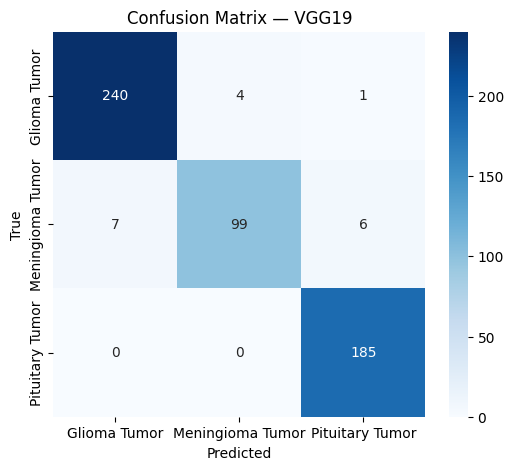

Fold: 1 block 3


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,426,635 (211.44 MB)

 Trainable params: 17,700,355 (67.52 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

 Optimizer params: 35,400,712 (135.04 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9778 - loss: 0.0225
Epoch 1: val_accuracy improved from -inf to 0.92251, saving model to /kaggle/working/VGG19_block_3_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 52s 467ms/step - accuracy: 0.9778 - loss: 0.0225 - val_accuracy: 0.9225 - val_loss: 0.0951 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9789 - loss: 0.0160
Epoch 2: val_accuracy improved from 0.92251 to 0.97048, saving model to /kaggle/working/VGG19_block_3_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 234ms/step - accuracy: 0.9789 - loss: 0.0160 - val_accuracy: 0.9705 - val_loss: 0.0433 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9811 - loss: 0.0154
Epoch 3: val_accuracy did not improve from 0.97048
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - accuracy: 0.9811 - loss: 0.0154 - val_accuracy: 0.9410 - val_loss: 0.0794 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

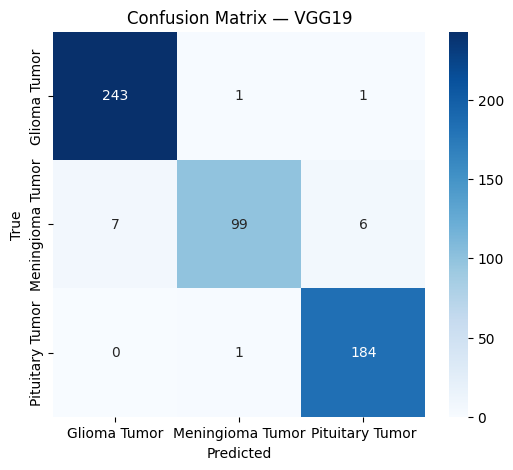

Fold: 1 block 2


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,557,451 (227.19 MB)

 Trainable params: 19,765,763 (75.40 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 39,531,528 (150.80 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9700 - loss: 0.0300
Epoch 1: val_accuracy improved from -inf to 0.95203, saving model to /kaggle/working/VGG19_block_2_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 514ms/step - accuracy: 0.9700 - loss: 0.0299 - val_accuracy: 0.9520 - val_loss: 0.0720 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9787 - loss: 0.0190
Epoch 2: val_accuracy improved from 0.95203 to 0.96494, saving model to /kaggle/working/VGG19_block_2_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.9787 - loss: 0.0191 - val_accuracy: 0.9649 - val_loss: 0.0220 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9855 - loss: 0.0138
Epoch 3: val_accuracy did not improve from 0.96494
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 244ms/step - accuracy: 0.9855 - loss: 0.0138 - val_accuracy: 0.9613 - val_loss: 0.0526 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

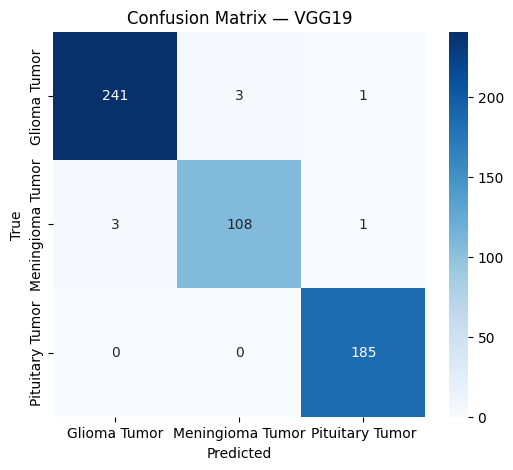

Fold: 1 block 1


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,000,331 (228.88 MB)

 Trainable params: 19,987,203 (76.25 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 39,974,408 (152.49 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9798 - loss: 0.0162
Epoch 1: val_accuracy improved from -inf to 0.95756, saving model to /kaggle/working/VGG19_block_1_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 65s 589ms/step - accuracy: 0.9798 - loss: 0.0162 - val_accuracy: 0.9576 - val_loss: 0.0351 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9921 - loss: 0.0084
Epoch 2: val_accuracy did not improve from 0.95756
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - accuracy: 0.9920 - loss: 0.0084 - val_accuracy: 0.9446 - val_loss: 0.0718 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9849 - loss: 0.0141
Epoch 3: val_accuracy improved from 0.95756 to 0.97048, saving model to /kaggle/working/VGG19_block_1_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 297ms/step - accuracy: 0.9849 - loss: 0.0141 - val_accuracy: 0.9705 - val_loss: 0.0416 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

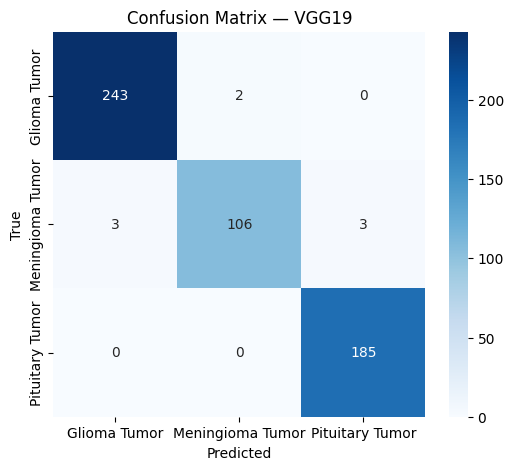

Fold: 2 block 6
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,025,923 (76.39 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.4665 - loss: 2.3341
Epoch 1: val_accuracy improved from -inf to 0.71134, saving model to /kaggle/working/VGG19_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.4671 - loss: 2.3271 - val_accuracy: 0.7113 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6338 - loss: 0.9329
Epoch 2: val_accuracy improved from 0.71134 to 0.75847, saving model to /kaggle/working/VGG19_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.6341 - loss: 0.9327 - val_accuracy: 0.7585 - val_loss: 0.4857 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7229 - loss: 0.6527
Epoch 3: val_accuracy improved from 0.75847 to 0.77320, saving model to /kaggle/working/VGG19_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.7229 - loss: 0.6525 - val_accuracy: 0.7732 - val_loss: 

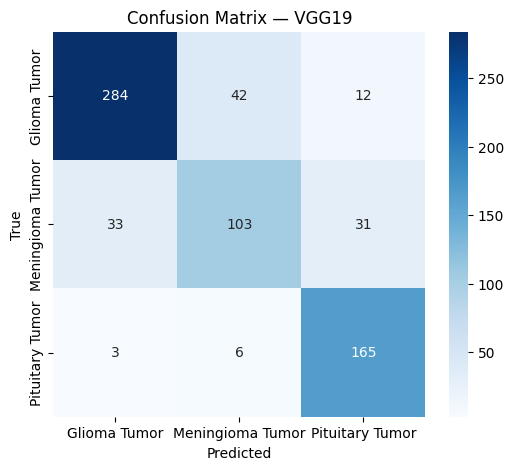

Fold: 2 block 5


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,029,003 (76.40 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8307 - loss: 0.1765
Epoch 1: val_accuracy improved from -inf to 0.82622, saving model to /kaggle/working/VGG19_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 287ms/step - accuracy: 0.8308 - loss: 0.1763 - val_accuracy: 0.8262 - val_loss: 0.1767 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8798 - loss: 0.1248
Epoch 2: val_accuracy improved from 0.82622 to 0.84536, saving model to /kaggle/working/VGG19_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.8798 - loss: 0.1247 - val_accuracy: 0.8454 - val_loss: 0.1811 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9031 - loss: 0.0800
Epoch 3: val_accuracy did not improve from 0.84536
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - accuracy: 0.9031 - loss: 0.0801 - val_accuracy: 0.8395 - val_loss: 0.1959 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

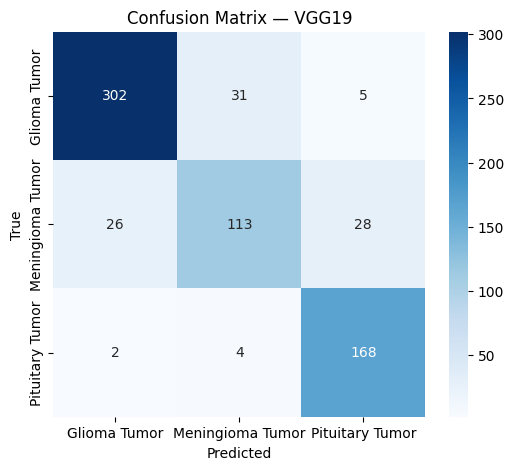

Fold: 2 block 4


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,907,467 (148.42 MB)

 Trainable params: 9,440,771 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 18,881,544 (72.03 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9116 - loss: 0.0706
Epoch 1: val_accuracy improved from -inf to 0.85125, saving model to /kaggle/working/VGG19_block_4_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 36s 357ms/step - accuracy: 0.9116 - loss: 0.0706 - val_accuracy: 0.8513 - val_loss: 0.1512 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9350 - loss: 0.0560
Epoch 2: val_accuracy did not improve from 0.85125
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.9351 - loss: 0.0560 - val_accuracy: 0.8513 - val_loss: 0.1541 - learning_rate: 1.0000e-05
Epoch 3/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9424 - loss: 0.0436
Epoch 3: val_accuracy improved from 0.85125 to 0.86598, saving model to /kaggle/working/VGG19_block_4_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.9423 - loss: 0.0436 - val_accuracy: 0.8660 - val_loss: 0.1936 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

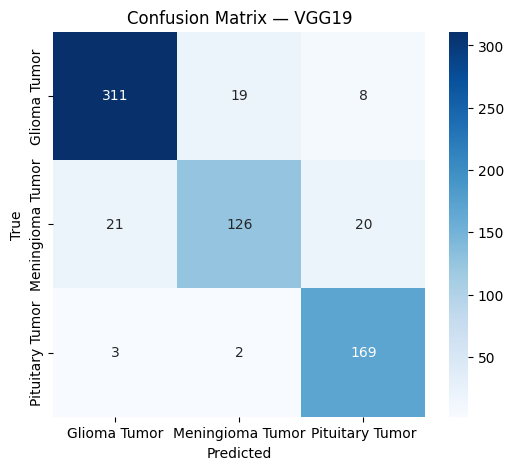

Fold: 2 block 3


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,426,635 (211.44 MB)

 Trainable params: 17,700,355 (67.52 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

 Optimizer params: 35,400,712 (135.04 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9561 - loss: 0.0381
Epoch 1: val_accuracy improved from -inf to 0.86451, saving model to /kaggle/working/VGG19_block_3_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 423ms/step - accuracy: 0.9562 - loss: 0.0381 - val_accuracy: 0.8645 - val_loss: 0.2330 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9579 - loss: 0.0328
Epoch 2: val_accuracy did not improve from 0.86451
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.9577 - loss: 0.0330 - val_accuracy: 0.8542 - val_loss: 0.1223 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9470 - loss: 0.0377
Epoch 3: val_accuracy improved from 0.86451 to 0.88071, saving model to /kaggle/working/VGG19_block_3_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.9472 - loss: 0.0376 - val_accuracy: 0.8807 - val_loss: 0.1229 - learning_rate: 1.0000e-05
Epoch 4/50
75/76 ━━━━

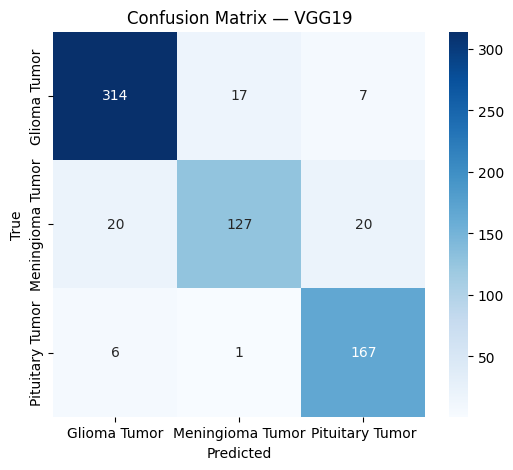

Fold: 2 block 2


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,557,451 (227.19 MB)

 Trainable params: 19,765,763 (75.40 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 39,531,528 (150.80 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9632 - loss: 0.0268
Epoch 1: val_accuracy improved from -inf to 0.88807, saving model to /kaggle/working/VGG19_block_2_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 46s 465ms/step - accuracy: 0.9633 - loss: 0.0268 - val_accuracy: 0.8881 - val_loss: 0.1481 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9744 - loss: 0.0201
Epoch 2: val_accuracy did not improve from 0.88807
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 253ms/step - accuracy: 0.9744 - loss: 0.0201 - val_accuracy: 0.8822 - val_loss: 0.1839 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9884 - loss: 0.0111
Epoch 3: val_accuracy improved from 0.88807 to 0.89985, saving model to /kaggle/working/VGG19_block_2_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.9883 - loss: 0.0112 - val_accuracy: 0.8999 - val_loss: 0.1303 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

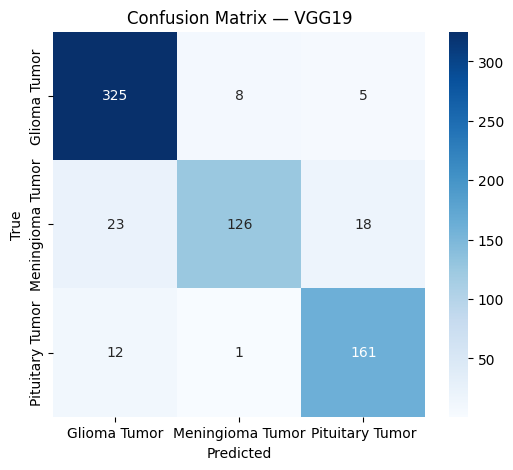

Fold: 2 block 1


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,000,331 (228.88 MB)

 Trainable params: 19,987,203 (76.25 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 39,974,408 (152.49 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9856 - loss: 0.0123
Epoch 1: val_accuracy improved from -inf to 0.93078, saving model to /kaggle/working/VGG19_block_1_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 533ms/step - accuracy: 0.9855 - loss: 0.0123 - val_accuracy: 0.9308 - val_loss: 0.0691 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9765 - loss: 0.0212
Epoch 2: val_accuracy did not improve from 0.93078
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 293ms/step - accuracy: 0.9766 - loss: 0.0211 - val_accuracy: 0.9131 - val_loss: 0.1310 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9904 - loss: 0.0076
Epoch 3: val_accuracy did not improve from 0.93078
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 292ms/step - accuracy: 0.9904 - loss: 0.0076 - val_accuracy: 0.8969 - val_loss: 0.2315 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9971 - loss: 0.0043

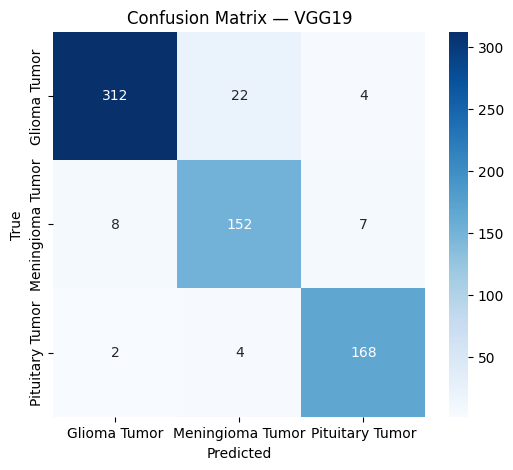

Fold: 3 block 6
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,025,923 (76.39 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4782 - loss: 1.6186
Epoch 1: val_accuracy improved from -inf to 0.66608, saving model to /kaggle/working/VGG19_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.4790 - loss: 1.6146 - val_accuracy: 0.6661 - val_loss: 0.6082 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6434 - loss: 0.8347
Epoch 2: val_accuracy improved from 0.66608 to 0.77448, saving model to /kaggle/working/VGG19_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.6438 - loss: 0.8334 - val_accuracy: 0.7745 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6935 - loss: 0.5989
Epoch 3: val_accuracy improved from 0.77448 to 0.77972, saving model to /kaggle/working/VGG19_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step - accuracy: 0.6938 - loss: 0.5982 - val_accuracy: 0.7797 - val_loss: 

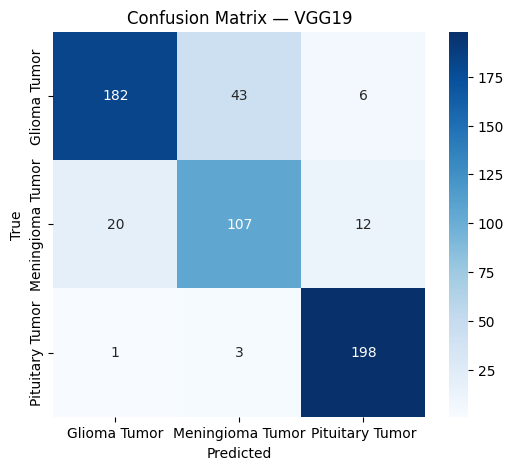

Fold: 3 block 5


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,029,003 (76.40 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8235 - loss: 0.1864
Epoch 1: val_accuracy improved from -inf to 0.86713, saving model to /kaggle/working/VGG19_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - accuracy: 0.8237 - loss: 0.1861 - val_accuracy: 0.8671 - val_loss: 0.1097 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8725 - loss: 0.1266
Epoch 2: val_accuracy improved from 0.86713 to 0.88462, saving model to /kaggle/working/VGG19_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.8725 - loss: 0.1265 - val_accuracy: 0.8846 - val_loss: 0.0858 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8848 - loss: 0.1003
Epoch 3: val_accuracy improved from 0.88462 to 0.88811, saving model to /kaggle/working/VGG19_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.8849 - loss: 0.1003 - val_accuracy: 0.8881 - va

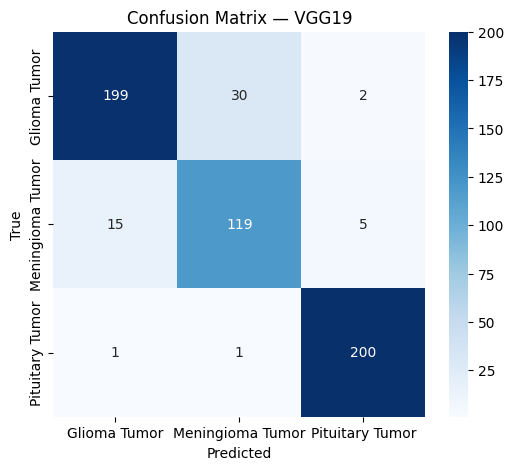

Fold: 3 block 4


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,907,467 (148.42 MB)

 Trainable params: 9,440,771 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 18,881,544 (72.03 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8998 - loss: 0.0830
Epoch 1: val_accuracy improved from -inf to 0.87413, saving model to /kaggle/working/VGG19_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 34s 303ms/step - accuracy: 0.8999 - loss: 0.0829 - val_accuracy: 0.8741 - val_loss: 0.1126 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9254 - loss: 0.0592
Epoch 2: val_accuracy improved from 0.87413 to 0.92308, saving model to /kaggle/working/VGG19_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step - accuracy: 0.9254 - loss: 0.0591 - val_accuracy: 0.9231 - val_loss: 0.0785 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9493 - loss: 0.0449
Epoch 3: val_accuracy did not improve from 0.92308
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.9493 - loss: 0.0449 - val_accuracy: 0.9056 - val_loss: 0.0873 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

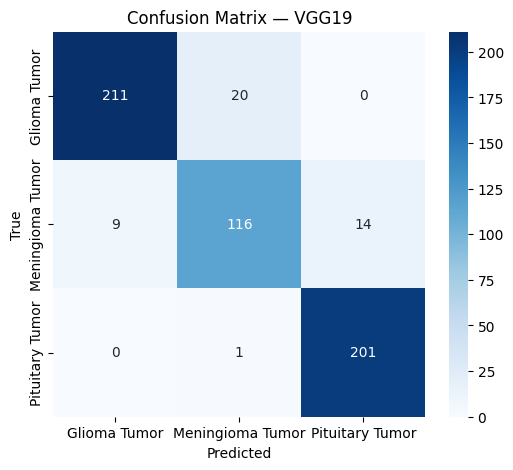

Fold: 3 block 3


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,426,635 (211.44 MB)

 Trainable params: 17,700,355 (67.52 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

 Optimizer params: 35,400,712 (135.04 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9343 - loss: 0.0580
Epoch 1: val_accuracy improved from -inf to 0.84790, saving model to /kaggle/working/VGG19_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 359ms/step - accuracy: 0.9344 - loss: 0.0579 - val_accuracy: 0.8479 - val_loss: 0.2267 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9547 - loss: 0.0419
Epoch 2: val_accuracy improved from 0.84790 to 0.90909, saving model to /kaggle/working/VGG19_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step - accuracy: 0.9547 - loss: 0.0419 - val_accuracy: 0.9091 - val_loss: 0.0877 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9550 - loss: 0.0335
Epoch 3: val_accuracy did not improve from 0.90909
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - accuracy: 0.9550 - loss: 0.0335 - val_accuracy: 0.9021 - val_loss: 0.1117 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

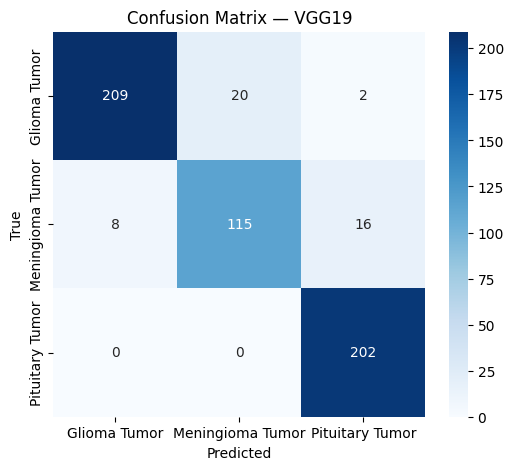

Fold: 3 block 2


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,557,451 (227.19 MB)

 Trainable params: 19,765,763 (75.40 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 39,531,528 (150.80 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9693 - loss: 0.0227
Epoch 1: val_accuracy improved from -inf to 0.89685, saving model to /kaggle/working/VGG19_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 397ms/step - accuracy: 0.9693 - loss: 0.0227 - val_accuracy: 0.8969 - val_loss: 0.1867 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9683 - loss: 0.0212
Epoch 2: val_accuracy improved from 0.89685 to 0.93007, saving model to /kaggle/working/VGG19_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.9684 - loss: 0.0212 - val_accuracy: 0.9301 - val_loss: 0.0958 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9781 - loss: 0.0204
Epoch 3: val_accuracy did not improve from 0.93007
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.9782 - loss: 0.0204 - val_accuracy: 0.9213 - val_loss: 0.1415 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

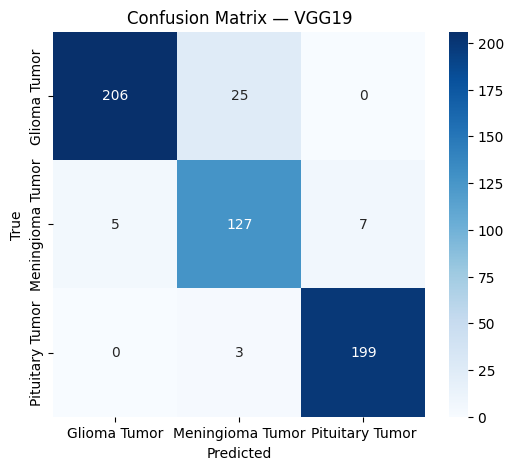

Fold: 3 block 1


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,000,331 (228.88 MB)

 Trainable params: 19,987,203 (76.25 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 39,974,408 (152.49 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9665 - loss: 0.0269
Epoch 1: val_accuracy improved from -inf to 0.91434, saving model to /kaggle/working/VGG19_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 48s 453ms/step - accuracy: 0.9666 - loss: 0.0268 - val_accuracy: 0.9143 - val_loss: 0.1850 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9790 - loss: 0.0194
Epoch 2: val_accuracy improved from 0.91434 to 0.91958, saving model to /kaggle/working/VGG19_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.9790 - loss: 0.0194 - val_accuracy: 0.9196 - val_loss: 0.1246 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9894 - loss: 0.0104
Epoch 3: val_accuracy improved from 0.91958 to 0.92657, saving model to /kaggle/working/VGG19_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.9894 - loss: 0.0105 - val_accuracy: 0.9266 - va

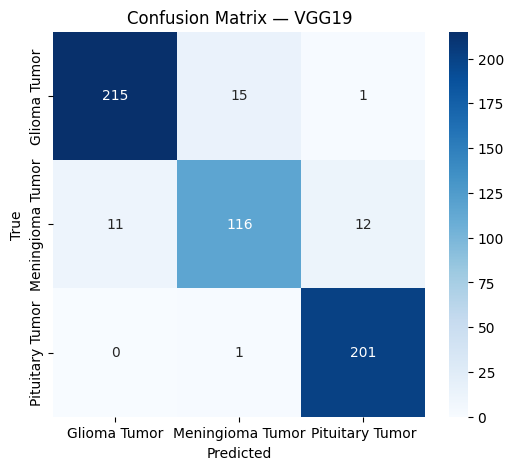

Fold: 4 block 6
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,025,923 (76.39 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4052 - loss: 2.4072
Epoch 1: val_accuracy improved from -inf to 0.55892, saving model to /kaggle/working/VGG19_block_6_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.4061 - loss: 2.3995 - val_accuracy: 0.5589 - val_loss: 0.9152 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6178 - loss: 1.0710
Epoch 2: val_accuracy improved from 0.55892 to 0.66401, saving model to /kaggle/working/VGG19_block_6_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.6181 - loss: 1.0688 - val_accuracy: 0.6640 - val_loss: 0.5904 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6762 - loss: 0.7686
Epoch 3: val_accuracy improved from 0.66401 to 0.77389, saving model to /kaggle/working/VGG19_block_6_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 0.6764 - loss: 0.7675 - val_accuracy: 0.7739 - val_loss: 

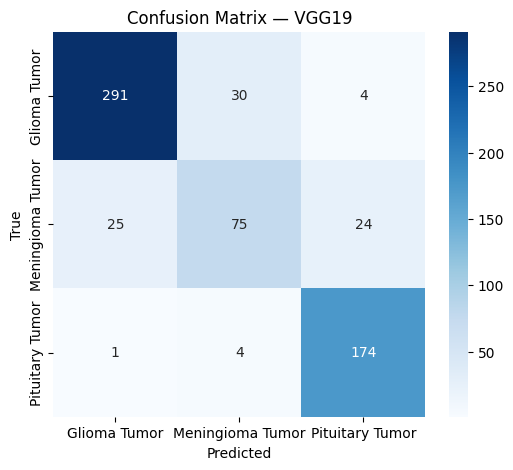

Fold: 4 block 5


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,029,003 (76.40 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8210 - loss: 0.1667
Epoch 1: val_accuracy improved from -inf to 0.91083, saving model to /kaggle/working/VGG19_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 269ms/step - accuracy: 0.8211 - loss: 0.1665 - val_accuracy: 0.9108 - val_loss: 0.0878 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8556 - loss: 0.1199
Epoch 2: val_accuracy did not improve from 0.91083
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.8556 - loss: 0.1199 - val_accuracy: 0.8726 - val_loss: 0.1041 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8882 - loss: 0.0879
Epoch 3: val_accuracy improved from 0.91083 to 0.91720, saving model to /kaggle/working/VGG19_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.8883 - loss: 0.0878 - val_accuracy: 0.9172 - val_loss: 0.0795 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━

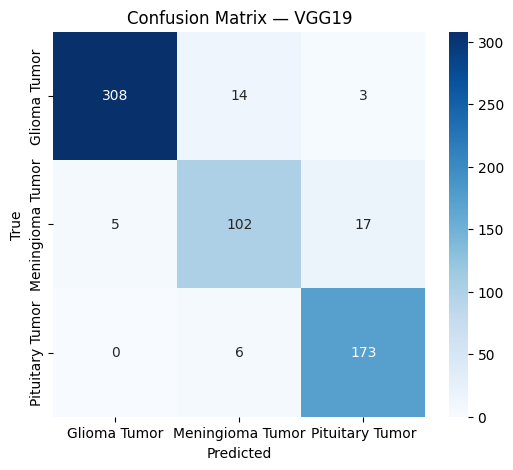

Fold: 4 block 4


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,907,467 (148.42 MB)

 Trainable params: 9,440,771 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 18,881,544 (72.03 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9412 - loss: 0.0562
Epoch 1: val_accuracy improved from -inf to 0.91242, saving model to /kaggle/working/VGG19_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.9411 - loss: 0.0562 - val_accuracy: 0.9124 - val_loss: 0.0976 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9510 - loss: 0.0428
Epoch 2: val_accuracy improved from 0.91242 to 0.92994, saving model to /kaggle/working/VGG19_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.9509 - loss: 0.0429 - val_accuracy: 0.9299 - val_loss: 0.0853 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9453 - loss: 0.0425
Epoch 3: val_accuracy improved from 0.92994 to 0.93153, saving model to /kaggle/working/VGG19_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - accuracy: 0.9454 - loss: 0.0424 - val_accuracy: 0.9315 - va

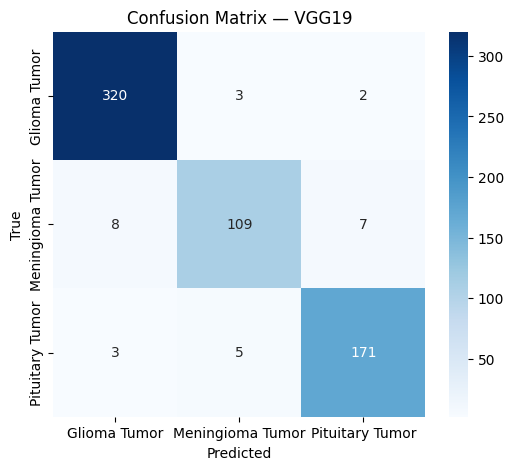

Fold: 4 block 3


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,426,635 (211.44 MB)

 Trainable params: 17,700,355 (67.52 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

 Optimizer params: 35,400,712 (135.04 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9543 - loss: 0.0377
Epoch 1: val_accuracy improved from -inf to 0.92675, saving model to /kaggle/working/VGG19_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 365ms/step - accuracy: 0.9543 - loss: 0.0377 - val_accuracy: 0.9268 - val_loss: 0.0849 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9638 - loss: 0.0301
Epoch 2: val_accuracy improved from 0.92675 to 0.93312, saving model to /kaggle/working/VGG19_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.9638 - loss: 0.0301 - val_accuracy: 0.9331 - val_loss: 0.0827 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9743 - loss: 0.0223
Epoch 3: val_accuracy did not improve from 0.93312
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 225ms/step - accuracy: 0.9744 - loss: 0.0222 - val_accuracy: 0.9283 - val_loss: 0.1107 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━

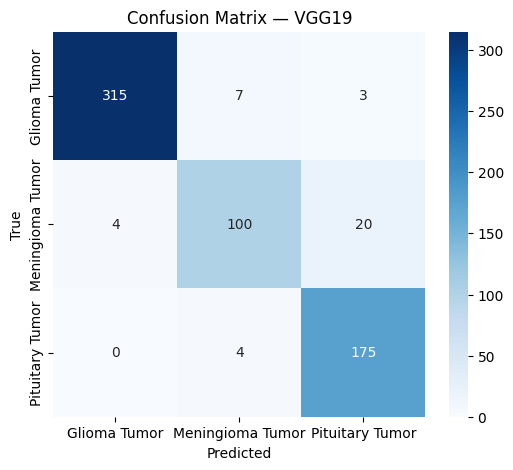

Fold: 4 block 2


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,557,451 (227.19 MB)

 Trainable params: 19,765,763 (75.40 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 39,531,528 (150.80 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9798 - loss: 0.0166
Epoch 1: val_accuracy improved from -inf to 0.91879, saving model to /kaggle/working/VGG19_block_2_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 407ms/step - accuracy: 0.9798 - loss: 0.0166 - val_accuracy: 0.9188 - val_loss: 0.2131 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9843 - loss: 0.0143
Epoch 2: val_accuracy improved from 0.91879 to 0.92834, saving model to /kaggle/working/VGG19_block_2_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9843 - loss: 0.0144 - val_accuracy: 0.9283 - val_loss: 0.1058 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9798 - loss: 0.0171
Epoch 3: val_accuracy did not improve from 0.92834
78/78 ━━━━━━━━━━━━━━━━━━━━ 24s 251ms/step - accuracy: 0.9798 - loss: 0.0171 - val_accuracy: 0.9013 - val_loss: 0.1516 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━

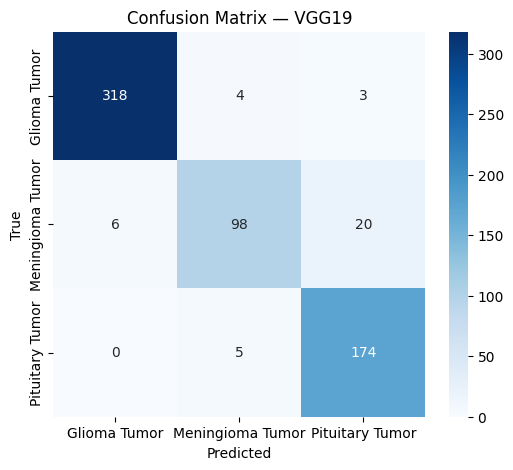

Fold: 4 block 1


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,000,331 (228.88 MB)

 Trainable params: 19,987,203 (76.25 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 39,974,408 (152.49 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9835 - loss: 0.0136
Epoch 1: val_accuracy improved from -inf to 0.95860, saving model to /kaggle/working/VGG19_block_1_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 47s 456ms/step - accuracy: 0.9835 - loss: 0.0137 - val_accuracy: 0.9586 - val_loss: 0.0645 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9831 - loss: 0.0129
Epoch 2: val_accuracy did not improve from 0.95860
78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 289ms/step - accuracy: 0.9832 - loss: 0.0129 - val_accuracy: 0.9411 - val_loss: 0.0975 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9898 - loss: 0.0088
Epoch 3: val_accuracy did not improve from 0.95860
78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 289ms/step - accuracy: 0.9898 - loss: 0.0088 - val_accuracy: 0.9061 - val_loss: 0.2179 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9918 - loss: 0.0095

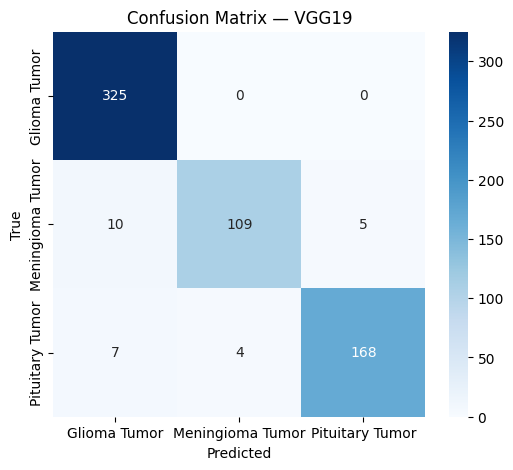

Fold: 5 block 6
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,025,923 (76.39 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.4435 - loss: 2.3985
Epoch 1: val_accuracy improved from -inf to 0.62053, saving model to /kaggle/working/VGG19_block_6_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.4443 - loss: 2.3906 - val_accuracy: 0.6205 - val_loss: 0.8733 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6618 - loss: 0.7799
Epoch 2: val_accuracy improved from 0.62053 to 0.70295, saving model to /kaggle/working/VGG19_block_6_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.6619 - loss: 0.7795 - val_accuracy: 0.7030 - val_loss: 0.7025 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7183 - loss: 0.6104
Epoch 3: val_accuracy improved from 0.70295 to 0.73250, saving model to /kaggle/working/VGG19_block_6_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.7184 - loss: 0.6099 - val_accuracy: 0.7325 - val_loss: 

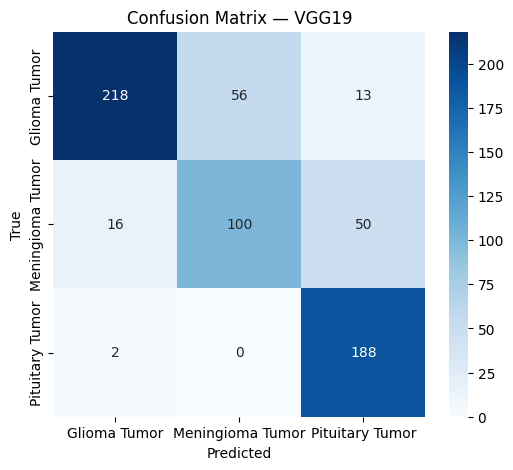

Fold: 5 block 5


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,029,003 (76.40 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8114 - loss: 0.2172
Epoch 1: val_accuracy improved from -inf to 0.77605, saving model to /kaggle/working/VGG19_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 271ms/step - accuracy: 0.8115 - loss: 0.2167 - val_accuracy: 0.7760 - val_loss: 0.3331 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8561 - loss: 0.1273
Epoch 2: val_accuracy improved from 0.77605 to 0.77760, saving model to /kaggle/working/VGG19_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.8564 - loss: 0.1270 - val_accuracy: 0.7776 - val_loss: 0.3916 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8895 - loss: 0.0856
Epoch 3: val_accuracy improved from 0.77760 to 0.83204, saving model to /kaggle/working/VGG19_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.8896 - loss: 0.0856 - val_accuracy: 0.8320 - va

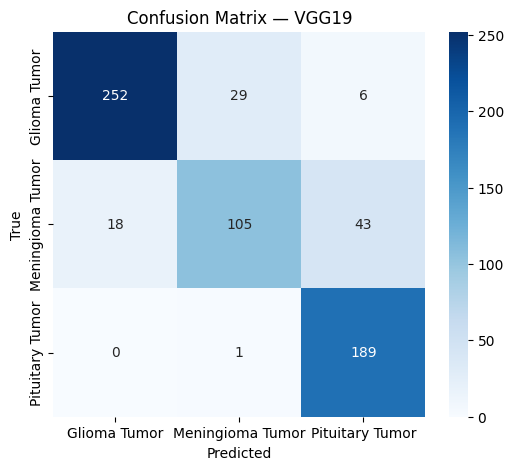

Fold: 5 block 4


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,907,467 (148.42 MB)

 Trainable params: 9,440,771 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

 Optimizer params: 18,881,544 (72.03 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9344 - loss: 0.0512
Epoch 1: val_accuracy improved from -inf to 0.82737, saving model to /kaggle/working/VGG19_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 311ms/step - accuracy: 0.9343 - loss: 0.0513 - val_accuracy: 0.8274 - val_loss: 0.3864 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9610 - loss: 0.0378
Epoch 2: val_accuracy improved from 0.82737 to 0.85070, saving model to /kaggle/working/VGG19_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.9610 - loss: 0.0379 - val_accuracy: 0.8507 - val_loss: 0.4308 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9463 - loss: 0.0438
Epoch 3: val_accuracy improved from 0.85070 to 0.85226, saving model to /kaggle/working/VGG19_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.9464 - loss: 0.0437 - val_accuracy: 0.8523 - va

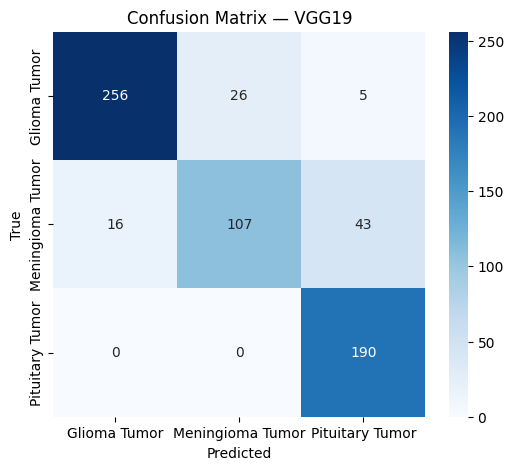

Fold: 5 block 3


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,426,635 (211.44 MB)

 Trainable params: 17,700,355 (67.52 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

 Optimizer params: 35,400,712 (135.04 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9665 - loss: 0.0300
Epoch 1: val_accuracy improved from -inf to 0.86936, saving model to /kaggle/working/VGG19_block_3_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 375ms/step - accuracy: 0.9665 - loss: 0.0300 - val_accuracy: 0.8694 - val_loss: 0.3862 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9646 - loss: 0.0257
Epoch 2: val_accuracy did not improve from 0.86936
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.9647 - loss: 0.0256 - val_accuracy: 0.8554 - val_loss: 0.5521 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9726 - loss: 0.0201
Epoch 3: val_accuracy did not improve from 0.86936
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.9726 - loss: 0.0201 - val_accuracy: 0.8631 - val_loss: 0.5466 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9819 - loss: 0.0191

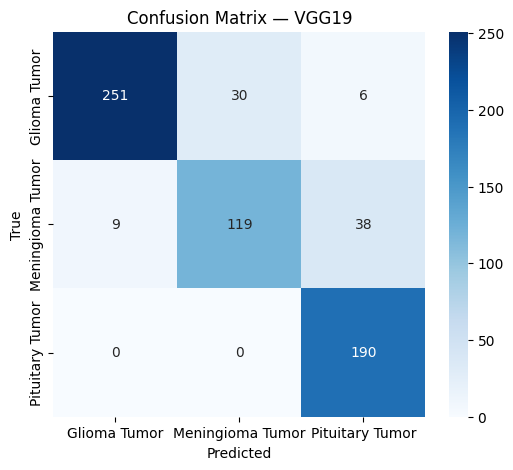

Fold: 5 block 2


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,557,451 (227.19 MB)

 Trainable params: 19,765,763 (75.40 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 39,531,528 (150.80 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9705 - loss: 0.0242
Epoch 1: val_accuracy improved from -inf to 0.85848, saving model to /kaggle/working/VGG19_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 412ms/step - accuracy: 0.9705 - loss: 0.0242 - val_accuracy: 0.8585 - val_loss: 0.4303 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9710 - loss: 0.0193
Epoch 2: val_accuracy did not improve from 0.85848
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.9711 - loss: 0.0192 - val_accuracy: 0.7512 - val_loss: 1.0762 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9729 - loss: 0.0299
Epoch 3: val_accuracy improved from 0.85848 to 0.86936, saving model to /kaggle/working/VGG19_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 358ms/step - accuracy: 0.9729 - loss: 0.0298 - val_accuracy: 0.8694 - val_loss: 0.5404 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━

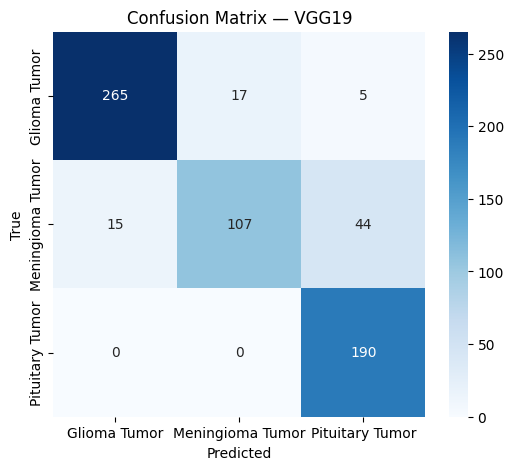

Fold: 5 block 1


Model: "VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,000,331 (228.88 MB)

 Trainable params: 19,987,203 (76.25 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 39,974,408 (152.49 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9840 - loss: 0.0143
Epoch 1: val_accuracy improved from -inf to 0.87558, saving model to /kaggle/working/VGG19_block_1_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 47s 464ms/step - accuracy: 0.9839 - loss: 0.0144 - val_accuracy: 0.8756 - val_loss: 0.5158 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9884 - loss: 0.0104
Epoch 2: val_accuracy improved from 0.87558 to 0.89425, saving model to /kaggle/working/VGG19_block_1_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 305ms/step - accuracy: 0.9884 - loss: 0.0104 - val_accuracy: 0.8942 - val_loss: 0.3622 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9855 - loss: 0.0110
Epoch 3: val_accuracy did not improve from 0.89425
77/77 ━━━━━━━━━━━━━━━━━━━━ 27s 292ms/step - accuracy: 0.9855 - loss: 0.0110 - val_accuracy: 0.8585 - val_loss: 0.5681 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━

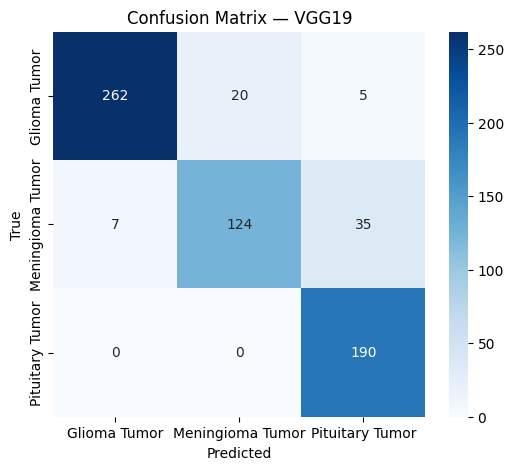

In [18]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b6.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.8819188475608826,
  0.8129602074623108,
  0.8513985872268677,
  0.8598726391792297,
  0.7869362235069275],
 [0.9317343235015869,
  0.8586156368255615,
  0.9055944085121155,
  0.9283439517021179,
  0.8491446375846863],
 [0.9667896628379822,
  0.892488956451416,
  0.9230769276618958,
  0.9554139971733093,
  0.8600311279296875],
 [0.9704797267913818,
  0.8954344391822815,
  0.9195803999900818,
  0.9394904375076294,
  0.870917558670044],
 [0.9852398633956909,
  0.9013254642486572,
  0.9300699234008789,
  0.9394904375076294,
  0.8740279674530029],
 [0.9852398633956909,
  0.9307805299758911,
  0.9300699234008789,
  0.9585987329483032,
  0.8958009481430054]]

In [20]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 83.86%
Accuracy unfreeze block 5 - block 6: 89.47%
Accuracy unfreeze block 4 - block 6: 91.96%
Accuracy unfreeze block 3 - block 6: 91.92%
Accuracy unfreeze block 2 - block 6: 92.60%
Accuracy unfreeze block 1 - block 6: 94.01%
